## 1 Setup & Daten laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 20
SIL_SAMPLE   = 3000   # Stichprobe für Silhouette (O(n^2) -> auf 21k zu teuer)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv("cleaned_house_data_new.csv")

clustering_cols = [c for c in df.columns if not c.startswith('prof_')]
X = df[clustering_cols].values                                    # nur die 6 Cluster-Features
profile = df[[c for c in df.columns if c.startswith('prof_')]]    # prof_price/waterfront/grade

print("Clustering auf:", clustering_cols)
print("Profil-Spalten:", list(profile.columns))
print("Shape gesamt:", df.shape, "| X:", X.shape)               # X sollte (21420, 6) sein
print("Fehlende Werte gesamt:", int(df.isna().sum().sum()))
df.head()

Clustering auf: ['bedrooms', 'luxury_score', 'distance_to_center', 'log_lot', 'lat', 'long']
Profil-Spalten: ['prof_price', 'prof_waterfront', 'prof_grade']
Shape gesamt: (21420, 9) | X: (21420, 6)
Fehlende Werte gesamt: 0


,bedrooms,luxury_score,distance_to_center,log_lot,lat,long,prof_price,prof_waterfront,prof_grade
0,-0.412580,-0.474253,-0.337180,-0.014981,1.483574,-0.889401,313000.0,0,7
1,1.802323,4.843636,-1.280274,0.133702,0.536149,-1.088283,2384000.0,0,10
2,-0.412580,-0.141885,0.813705,0.440966,-1.392617,0.445947,342000.0,0,8
3,-0.412580,-0.141885,0.145094,0.001398,0.422862,0.708755,420000.0,0,8
4,0.694872,-0.474253,0.249930,0.298124,0.886112,0.708755,550000.0,0,7


In [13]:
# Kurzer Skalen-Check: sollte Mittel ~0 und Std ~1 sein (aus M3)
df[clustering_cols].describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
bedrooms,0.0,1.0,-2.627,8.447
luxury_score,0.0,1.0,-1.804,5.841
distance_to_center,0.0,1.0,-1.542,6.751
log_lot,0.0,1.0,-3.027,5.894
lat,-0.0,1.0,-2.917,1.569
long,-0.0,1.0,-2.168,6.384


## 2  Kurze EDA: Verteilungen & Korrelationen

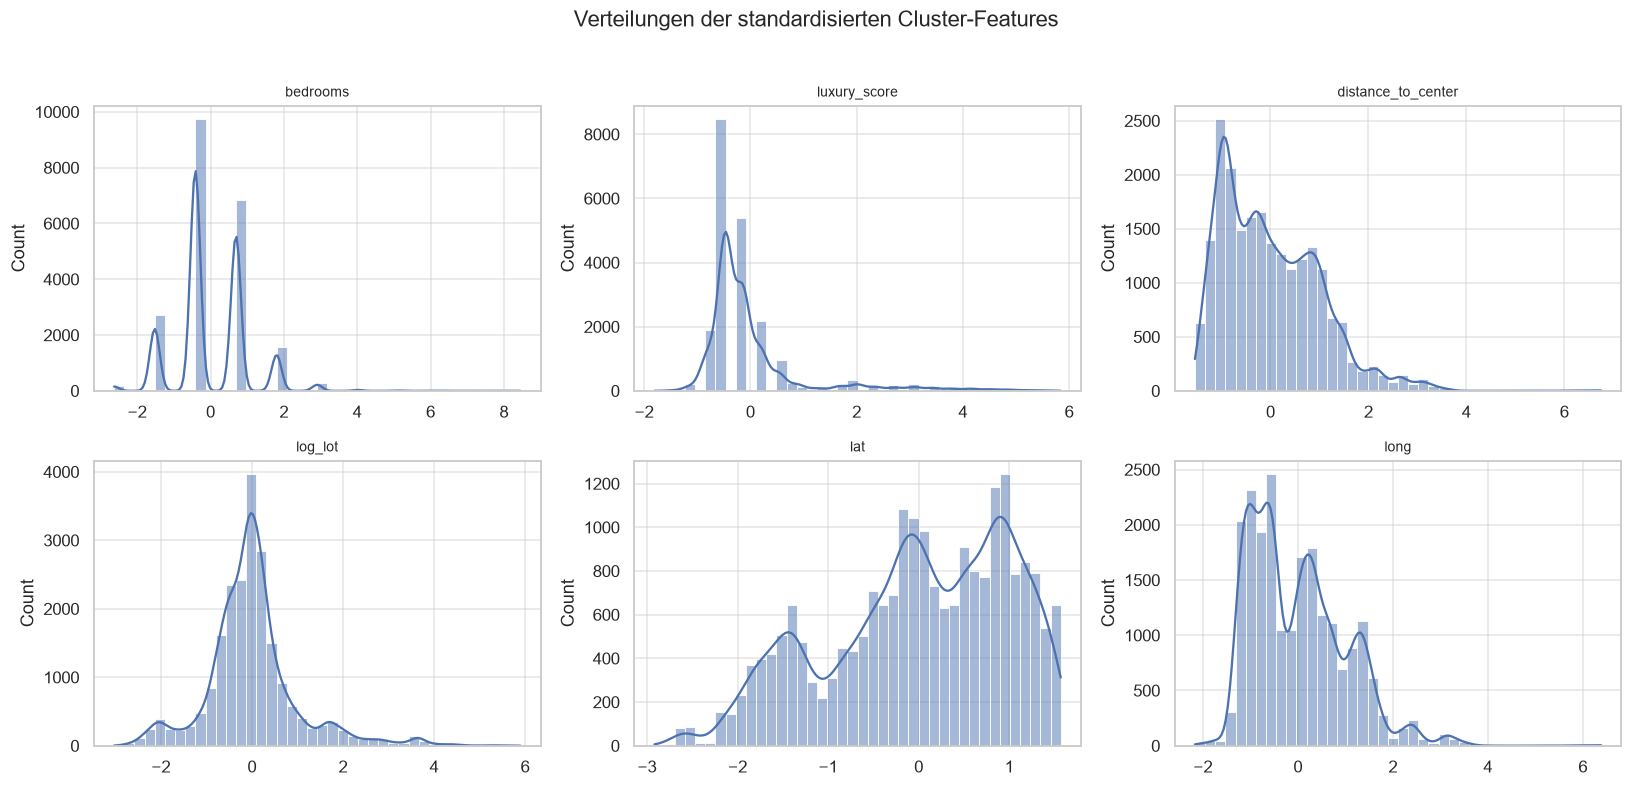

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), clustering_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Verteilungen der standardisierten Cluster-Features", y=1.02)
plt.tight_layout(); plt.show()

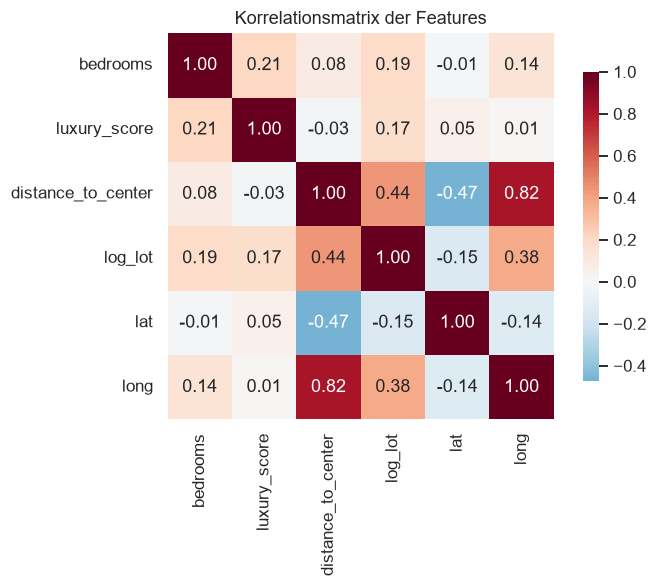

In [14]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[clustering_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Korrelationsmatrix der Features")
plt.tight_layout(); plt.show()

## 3 Wie viele Cluster? (Elbow · Silhouette · Davies-Bouldin)
Wir bestimmen $k$ **empirisch** mit K-Means über $k = 2 \dots 14$ und drei Kennzahlen:

- **SSE / Inertia (Elbow):** Knick im Verlauf → guter $k$-Kandidat.
- **Silhouette:** je höher, desto besser getrennt (Wertebereich −1…+1).
- **Davies-Bouldin:** je **niedriger**, desto besser getrennt (0 = ideal).


In [30]:
k_range = range(2, 9)
sse, sil, dbi = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    labels = km.labels_
    sse.append(km.inertia_)
    sil.append(silhouette_score(X, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE))
    dbi.append(davies_bouldin_score(X, labels))

metrics = pd.DataFrame({"k": list(k_range),
                        "SSE": sse,
                        "Silhouette": sil,
                        "Davies_Bouldin": dbi}).set_index("k")

# Anzeige mit k waagerecht (Spalten = k, Zeilen = Kennzahlen); metrics selbst bleibt
# unverändert, damit die Plots und idxmax()/idxmin() unten k weiter als Index nutzen.
metrics.T.round(3)

k,2,3,4,5,6,7,8
SSE,95254.949,80022.749,68957.101,59663.965,54044.112,49637.487,46802.560
Silhouette,0.255,0.277,0.276,0.233,0.250,0.246,0.224
Davies_Bouldin,1.541,1.305,1.364,1.349,1.297,1.237,1.305


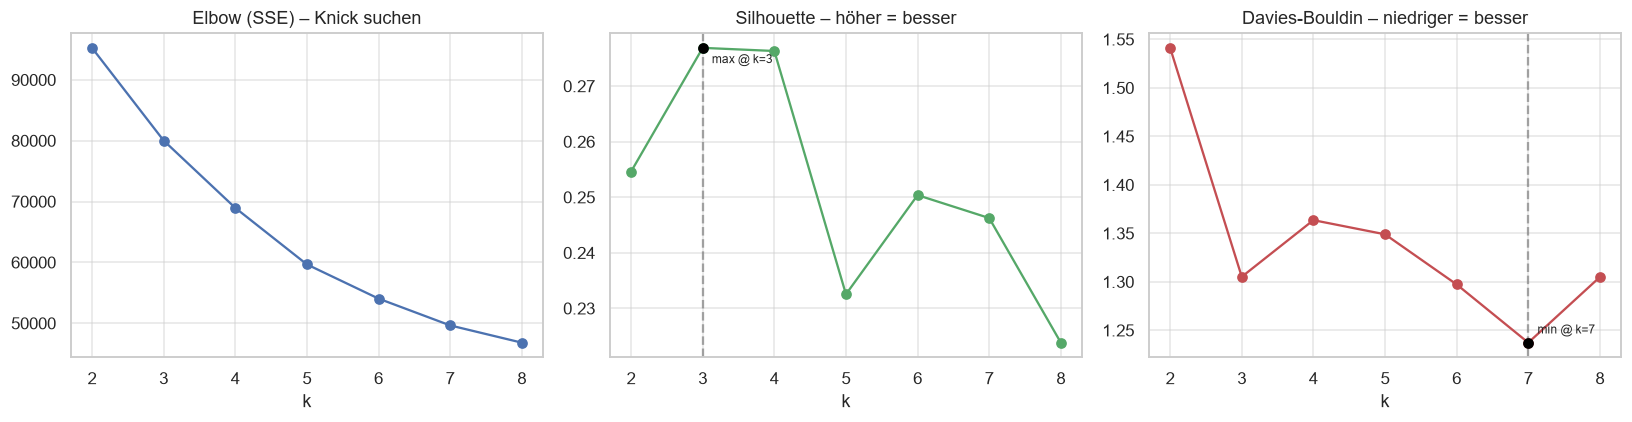

Bestes k nach Silhouette:     3
Bestes k nach Davies-Bouldin: 7


In [32]:
best_sil = metrics["Silhouette"].idxmax()
best_dbi = metrics["Davies_Bouldin"].idxmin()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(list(k_range), sse, "o-", color="#4C72B0"); ax[0].set_title("Elbow (SSE) – Knick suchen")
ax[1].plot(list(k_range), sil, "o-", color="#55A868"); ax[1].set_title("Silhouette – höher = besser")
ax[2].plot(list(k_range), dbi, "o-", color="#C44E52"); ax[2].set_title("Davies-Bouldin – niedriger = besser")

# Silhouette-Optimum markieren
ax[1].axvline(best_sil, ls="--", c="grey", alpha=.7)
ax[1].scatter([best_sil], [metrics.loc[best_sil, "Silhouette"]], color="black", zorder=5)
ax[1].annotate(f"max @ k={best_sil}", (best_sil, metrics.loc[best_sil, "Silhouette"]),
               textcoords="offset points", xytext=(6, -10), fontsize=8)

# Davies-Bouldin-Optimum markieren
ax[2].axvline(best_dbi, ls="--", c="grey", alpha=.7)
ax[2].scatter([best_dbi], [metrics.loc[best_dbi, "Davies_Bouldin"]], color="black", zorder=5)
ax[2].annotate(f"min @ k={best_dbi}", (best_dbi, metrics.loc[best_dbi, "Davies_Bouldin"]),
               textcoords="offset points", xytext=(6, 6), fontsize=8)

for a in ax:
    a.set_xlabel("k")
plt.tight_layout(); plt.show()

print(f"Bestes k nach Silhouette:     {best_sil}")
print(f"Bestes k nach Davies-Bouldin: {best_dbi}")

## 5 Algorithmen-Vergleich
Für jeden Algorithmus: fitten → Cluster im PCA-Raum plotten → Kennzahlen sammeln. Density-Verfahren (DBSCAN/HDBSCAN) bestimmen die Clusterzahl selbst und markieren Ausreißer als **Noise** (Label −1).

In [33]:
from matplotlib.lines import Line2D

results = []   # Sammel-Liste für die finale Vergleichstabelle

def evaluate(name, labels):
    # Kennzahlen robust berechnen (Noise -1 ausschliessen, >=2 Cluster noetig)
    labels = np.asarray(labels)
    mask = labels != -1
    uniq = set(labels[mask])
    n_clusters = len(uniq)
    n_noise = int((labels == -1).sum())
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask],
                               sample_size=min(SIL_SAMPLE, mask.sum()),
                               random_state=RANDOM_STATE)
        dbi = davies_bouldin_score(X[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan
    results.append({"Algorithmus": name, "n_Cluster": n_clusters,
                    "Noise": n_noise, "Silhouette": sil, "Davies_Bouldin": dbi})
    print(f"{name:16s} | Cluster: {n_clusters:2d} | Noise: {n_noise:5d} "
          f"| Silhouette: {sil:.3f} | DB: {dbi:.3f}")
    return labels

def plot_clusters(labels, title, emb=None, idx=None, ax=None,
                  xlabel="PC1", ylabel="PC2"):
    """Cluster in einer 2D-Projektion – feste Farbe pro Cluster, beschriftetes
    Zentrum und Legende (inkl. Größe), damit die Segmente klar erkennbar sind.

    emb : 2D-Koordinaten (default: X_pca). idx : optionale Punkt-Auswahl
    (z. B. t-SNE-Stichprobe) – dann werden labels[idx] geplottet.
    ax  : zum Einbetten in ein Grid; ohne ax wird eine eigene Figur erzeugt.
    """
    labels = np.asarray(labels)
    if emb is None:
        emb = X_pca
    if idx is not None:
        labels = labels[idx]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7.5, 6))

    # Cluster nach Größe: große zuerst zeichnen, kleine kommen oben drauf -> sichtbar
    clusters = sorted((c for c in np.unique(labels) if c != -1),
                      key=lambda c: (labels == c).sum(), reverse=True)
    cmap = plt.get_cmap("tab10" if len(clusters) <= 10 else "tab20")
    colors = {c: cmap(i % cmap.N) for i, c in enumerate(clusters)}

    # Noise dezent in den Hintergrund
    noise = labels == -1
    if noise.any():
        ax.scatter(emb[noise, 0], emb[noise, 1], c="lightgrey",
                   s=6, alpha=.30, linewidths=0, zorder=1)

    handles = []
    for i, c in enumerate(clusters):
        m = labels == c
        ax.scatter(emb[m, 0], emb[m, 1], color=colors[c],
                   s=14, alpha=.65, linewidths=0, zorder=2 + i)
        # Cluster-Zentrum hervorheben + beschriften (nur als Anker fürs Label)
        cx, cy = emb[m, 0].mean(), emb[m, 1].mean()
        ax.scatter(cx, cy, marker="o", s=280, color=colors[c],
                   edgecolor="black", linewidths=1.8, zorder=50)
        ax.text(cx, cy, str(c), color="black", fontsize=10, fontweight="bold",
                ha="center", va="center", zorder=51)
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                              markerfacecolor=colors[c], markeredgecolor="black",
                              label=f"Cluster {c}  (n={int(m.sum()):,})"))
    if noise.any():
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                              markerfacecolor="lightgrey", markeredgecolor="none",
                              label=f"Noise  (n={int(noise.sum()):,})"))

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(handles=handles, loc="best", framealpha=.9, fontsize=8)
    if own_fig:
        plt.tight_layout(); plt.show()

### 5.1 · K-Means

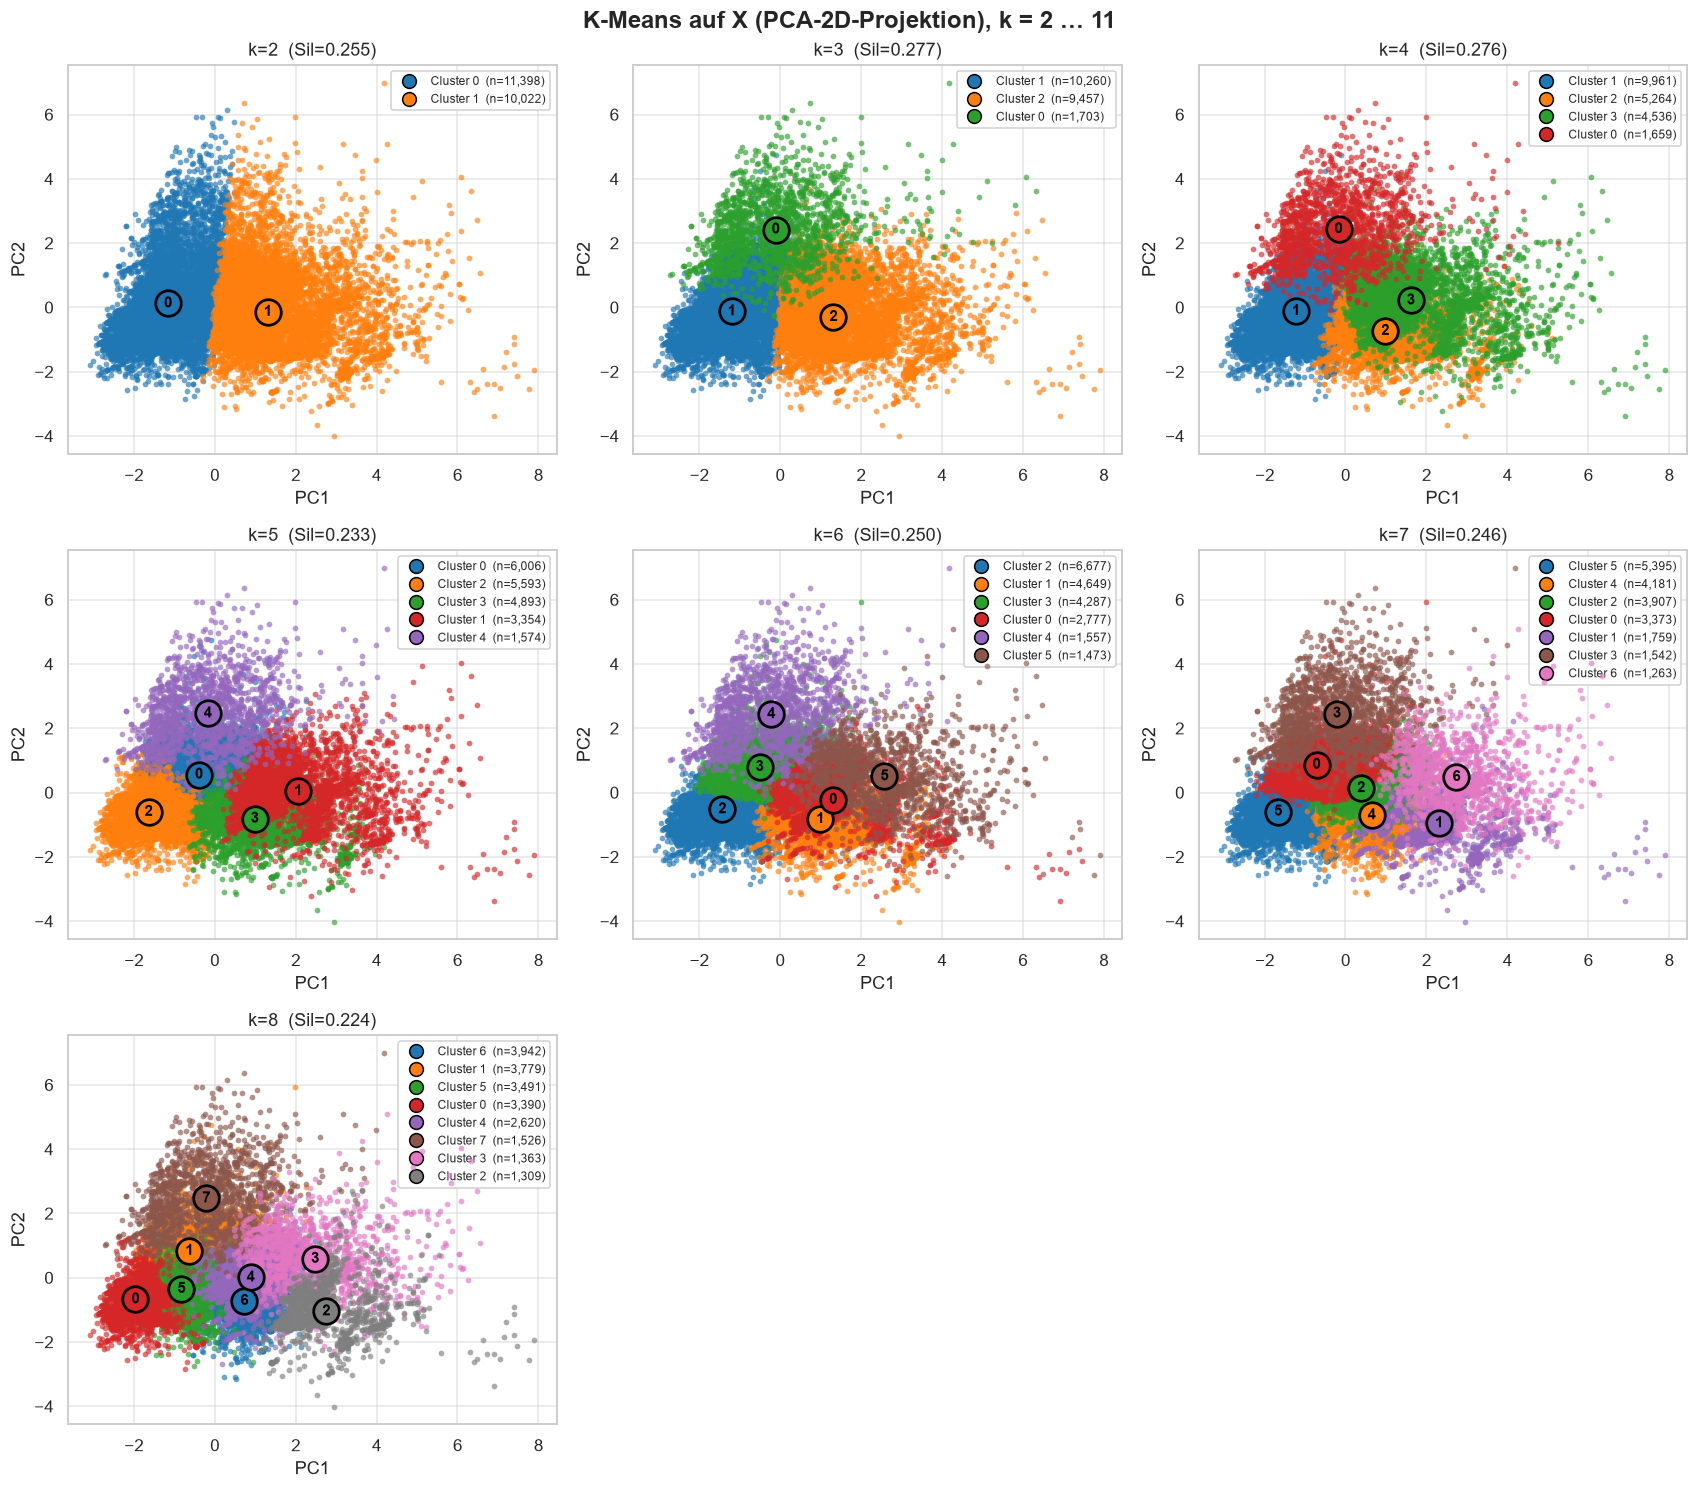

In [34]:
# 2D-Projektion EINMAL berechnen -> alle Panels vergleichbar
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

ks = list(range(2, 9))
ncols = 3
nrows = int(np.ceil(len(ks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows))
axes = axes.ravel()

for ax, k in zip(axes, ks):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    sil = silhouette_score(X, km.labels_,
                           sample_size=min(SIL_SAMPLE, len(X)),
                           random_state=RANDOM_STATE)
    plot_clusters(km.labels_, f"k={k}  (Sil={sil:.3f})", emb=X_pca, ax=ax)

for ax in axes[len(ks):]:
    ax.set_visible(False)

fig.suptitle("K-Means auf X (PCA-2D-Projektion), k = 2 … 11",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 · Hierarchical (Agglomerative, Ward)
Dendrogramm auf einer Zufalls-Stichprobe (Ward/Linkage ist $O(n^2)$ Speicher – für 21k unpraktisch, zur *Visualisierung* ist eine Stichprobe Standard. Das eigentliche Clustering fitten wir mit `AgglomerativeClustering` auf allen Punkten.

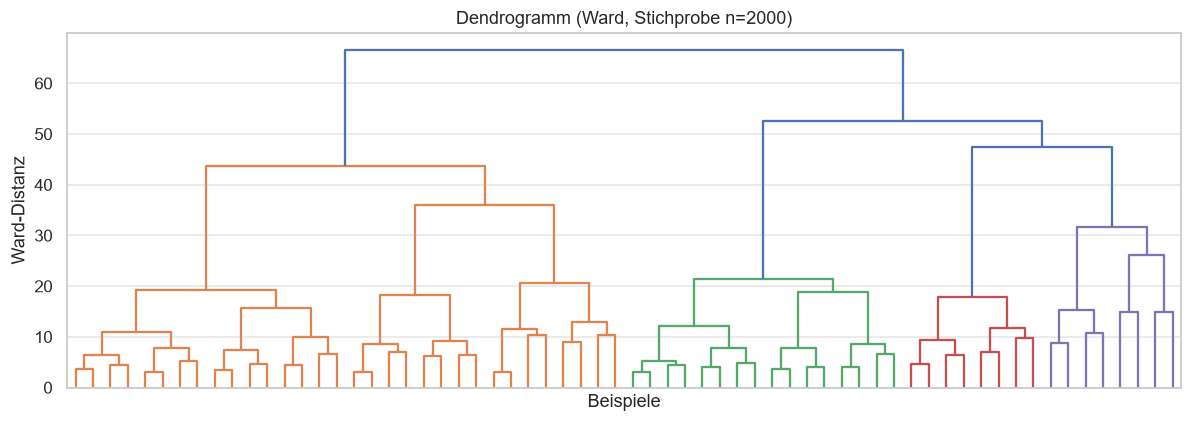

In [26]:
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X), size=2000, replace=False)
Z = linkage(X[idx], method="ward")

plt.figure(figsize=(11, 4))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True, color_threshold=None)
plt.title("Dendrogramm (Ward, Stichprobe n=2000)")
plt.xlabel("Beispiele"); plt.ylabel("Ward-Distanz")
plt.tight_layout(); plt.show()

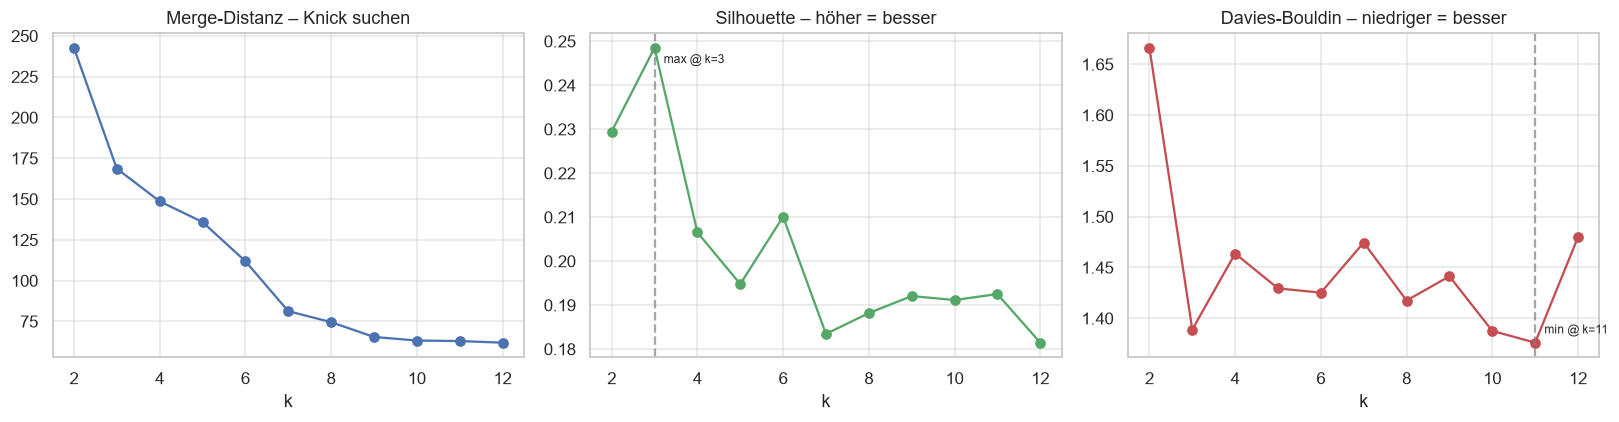

Ward-Optimum: Silhouette bei k=3, Davies-Bouldin bei k=11


k,2,3,4,5,6,7,8,9,10,11,12
Merge_Distanz,242.674,168.683,148.628,135.937,111.941,81.303,74.578,65.494,63.308,62.975,62.000
Silhouette,0.229,0.248,0.207,0.195,0.210,0.183,0.188,0.192,0.191,0.193,0.181
Davies_Bouldin,1.666,1.389,1.464,1.429,1.425,1.475,1.417,1.441,1.388,1.376,1.480


In [29]:
# Bevorzugt Ward selbst ein anderes k? (der Scan in §4 lief nur mit K-Means)
# Ward-Linkage EINMAL auf allen Punkten berechnen, dann je k schneiden (effizient).
from scipy.cluster.hierarchy import fcluster

Z_full = linkage(X, method="ward")          # O(n^2) Speicher, auf 21k noch machbar
ward_k = range(2, 9)
w_sil, w_dbi = [], []
for k in ward_k:
    lab = fcluster(Z_full, t=k, criterion="maxclust")
    w_sil.append(silhouette_score(X, lab, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE))
    w_dbi.append(davies_bouldin_score(X, lab))

# Ward-"Elbow": Ward hat kein SSE/Inertia wie K-Means. Das hierarchische Pendant sind
# die MERGE-DISTANZEN (Höhen im Dendrogramm) – die Distanz, bei der die Daten in k
# Cluster zerfallen. Ein Knick markiert (wie der SSE-Elbow) eine natürliche Clusterzahl.
heights_desc = np.sort(Z_full[:, 2])[::-1]
ward_merge = [heights_desc[k - 2] for k in ward_k]   # Höhe, um k Cluster zu bilden

ward_metrics = pd.DataFrame({"k": list(ward_k), "Merge_Distanz": ward_merge,
                             "Silhouette": w_sil, "Davies_Bouldin": w_dbi}).set_index("k")

w_best_sil = ward_metrics["Silhouette"].idxmax()
w_best_dbi = ward_metrics["Davies_Bouldin"].idxmin()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(list(ward_k), ward_merge, "o-", color="#4C72B0"); ax[0].set_title("Merge-Distanz – Knick suchen")
ax[1].plot(list(ward_k), w_sil, "o-", color="#55A868");     ax[1].set_title("Silhouette – höher = besser")
ax[2].plot(list(ward_k), w_dbi, "o-", color="#C44E52");     ax[2].set_title("Davies-Bouldin – niedriger = besser")

ax[1].axvline(w_best_sil, ls="--", c="grey", alpha=.7)
ax[1].annotate(f"max @ k={w_best_sil}", (w_best_sil, ward_metrics.loc[w_best_sil, "Silhouette"]),
               textcoords="offset points", xytext=(6, -10), fontsize=8)
ax[2].axvline(w_best_dbi, ls="--", c="grey", alpha=.7)
ax[2].annotate(f"min @ k={w_best_dbi}", (w_best_dbi, ward_metrics.loc[w_best_dbi, "Davies_Bouldin"]),
               textcoords="offset points", xytext=(6, 6), fontsize=8)

for a in ax:
    a.set_xlabel("k")
plt.tight_layout(); plt.show()

print(f"Ward-Optimum: Silhouette bei k={w_best_sil}, Davies-Bouldin bei k={w_best_dbi}")
ward_metrics.T.round(3)

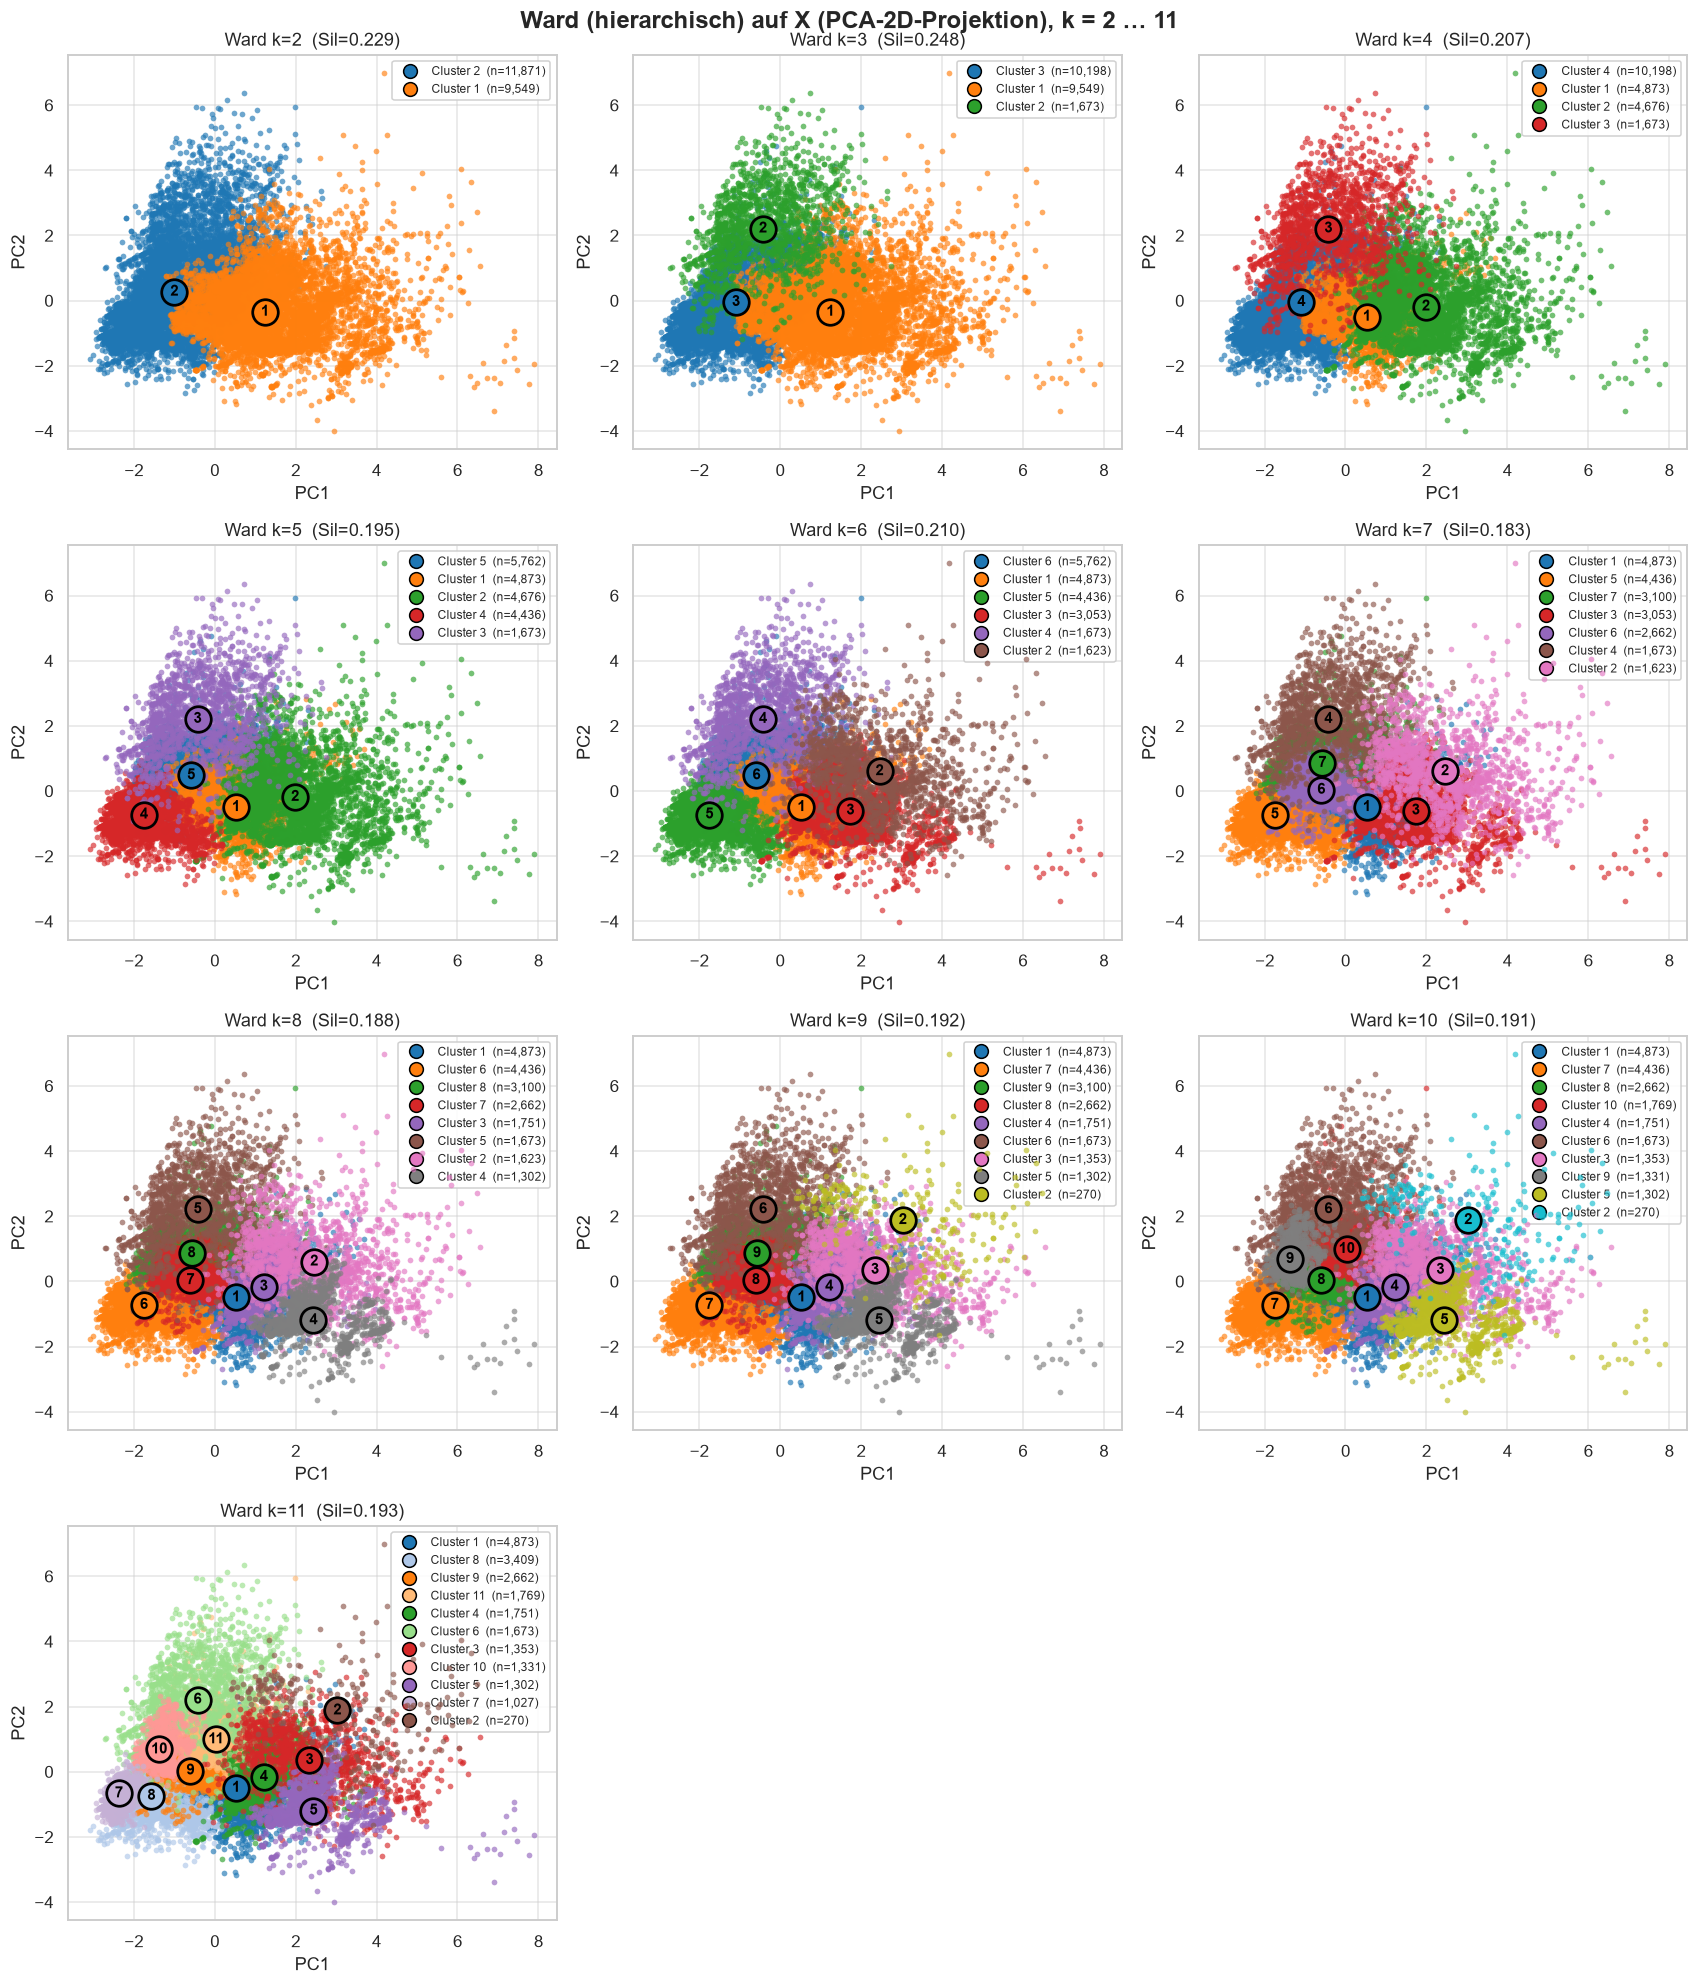

In [36]:
from scipy.cluster.hierarchy import fcluster

# Ward-Linkage EINMAL berechnen (wiederverwenden, falls aus dem Ward-Scan schon da)
try:
    Z_full
except NameError:
    Z_full = linkage(X, method="ward")

ks = list(range(2, 12))
ncols = 3
nrows = int(np.ceil(len(ks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows))
axes = axes.ravel()

for ax, k in zip(axes, ks):
    lab = fcluster(Z_full, t=k, criterion="maxclust")          # k Cluster aus dem Baum schneiden
    sil = silhouette_score(X, lab, sample_size=min(SIL_SAMPLE, len(X)),
                           random_state=RANDOM_STATE)
    plot_clusters(lab, f"Ward k={k}  (Sil={sil:.3f})", emb=X_pca, ax=ax)

for ax in axes[len(ks):]:
    ax.set_visible(False)

fig.suptitle("Ward (hierarchisch) auf X (PCA-2D-Projektion), k = 2 … 11",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 · DBSCAN
`eps` bestimmen wir über die **k-Distance-Kurve** (Distanz zum `min_samples`-ten Nachbarn, sortiert). Der Knick markiert eine sinnvolle Nachbarschafts-Größe. Faustregel `min_samples ≈ 2 · Anzahl Features`.

D = 6,  min_samples = 12,  gewähltes eps = 0.836


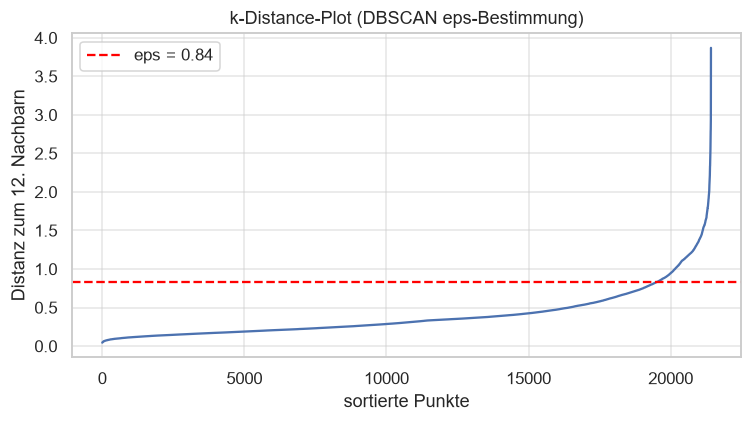

In [37]:
from sklearn.neighbors import NearestNeighbors

# Helfer: eps am Knie der k-Distance-Kurve.
# Die Kurve ist konvex (flach -> steiler Anstieg), liegt also UNTER der Sehne.
# Das Knie = Punkt mit maximalem Abstand UNTER der Sehne -> argmax(line - kd).
def knee_eps(X, ms):
    nn = NearestNeighbors(n_neighbors=ms).fit(X)
    kd = np.sort(nn.kneighbors(X)[0][:, -1])
    line = np.linspace(kd[0], kd[-1], len(kd))
    eps = kd[np.argmax(line - kd)]
    return eps, kd

min_samples = 2 * X.shape[1]                 # Faustregel 2*D = 12  (D = 6 Features)
eps, kdist = knee_eps(X, min_samples)
print(f"D = {X.shape[1]},  min_samples = {min_samples},  gewähltes eps = {eps:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(kdist)), kdist, color="#4C72B0")
plt.axhline(eps, ls="--", c="red", label=f"eps = {eps:.2f}")
plt.xlabel("sortierte Punkte"); plt.ylabel(f"Distanz zum {min_samples}. Nachbarn")
plt.title("k-Distance-Plot (DBSCAN eps-Bestimmung)"); plt.legend()
plt.tight_layout(); plt.show()

DBSCAN           | Cluster: 14 | Noise:  1095 | Silhouette: -0.061 | DB: 1.549


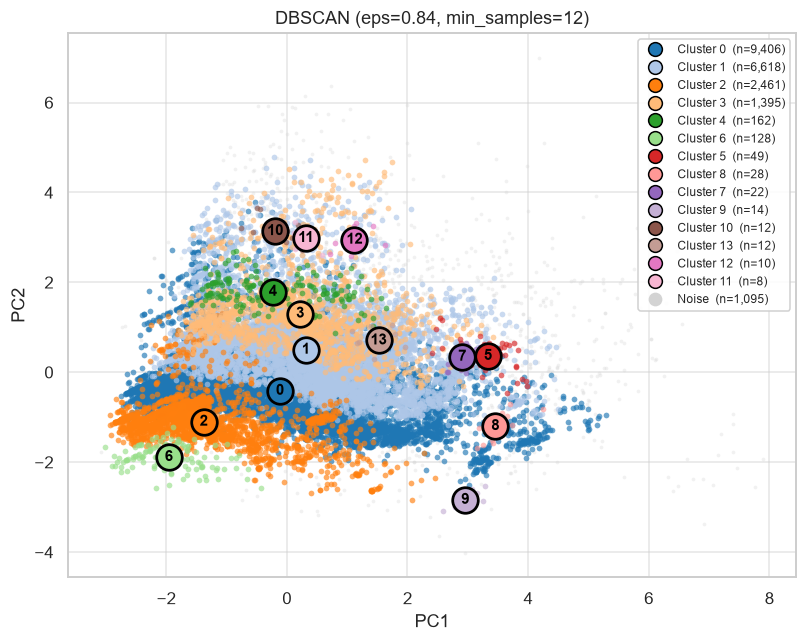

In [38]:
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels_db = evaluate("DBSCAN", db.labels_)
plot_clusters(labels_db, f"DBSCAN (eps={eps:.2f}, min_samples={min_samples})")

,min_samples,eps,eps_Quelle,Cluster,Noise,Noise_%
0,12,0.836,eps fest (Regel),14,1095,5.1
1,12,0.836,eps neu abgeleitet,14,1095,5.1
2,7,0.836,eps fest (Regel),18,796,3.7
3,7,0.713,eps neu abgeleitet,30,1152,5.4


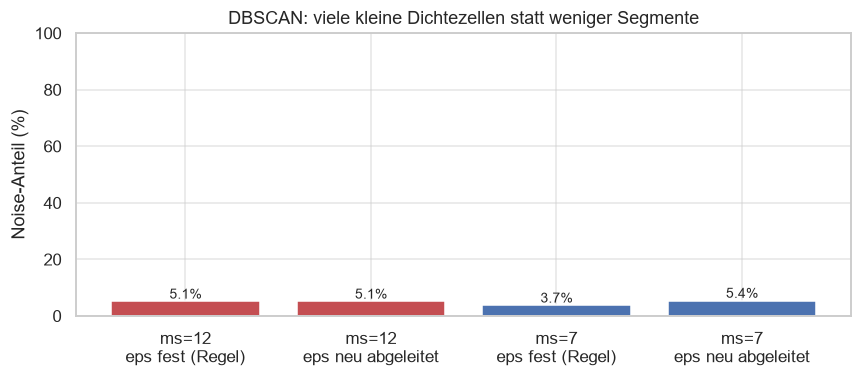

In [39]:
# Hängt das Ergebnis an min_samples? Faustregel 2*D=12 vs. Untergrenze D+1=7,
# je einmal mit festem eps (isoliert min_samples) und mit neu abgeleitetem eps.
ms_rule = 2 * X.shape[1]       # 12
ms_min  = X.shape[1] + 1       # 7
eps_ref, _ = knee_eps(X, ms_rule)

def dbscan_eval(ms, eps_val):
    lab = DBSCAN(eps=eps_val, min_samples=ms).fit(X).labels_
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    noise = int((lab == -1).sum())
    return nc, noise, round(noise / len(X) * 100, 1)

rows = []
for ms in (ms_rule, ms_min):
    for src, e in [("eps fest (Regel)", eps_ref), ("eps neu abgeleitet", knee_eps(X, ms)[0])]:
        nc, no, pc = dbscan_eval(ms, e)
        rows.append({"min_samples": ms, "eps": round(float(e), 3), "eps_Quelle": src,
                     "Cluster": nc, "Noise": no, "Noise_%": pc})
sens = pd.DataFrame(rows)
display(sens)

nl = chr(10)
labels_bar = [f"ms={r.min_samples}{nl}{r.eps_Quelle}" for r in sens.itertuples()]
plt.figure(figsize=(8, 3.6))
bars = plt.bar(labels_bar, sens["Noise_%"],
               color=["#C44E52", "#C44E52", "#4C72B0", "#4C72B0"])
plt.ylabel("Noise-Anteil (%)"); plt.ylim(0, 100)
plt.title("DBSCAN: viele kleine Dichtezellen statt weniger Segmente")
for b, v in zip(bars, sens["Noise_%"]):
    plt.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

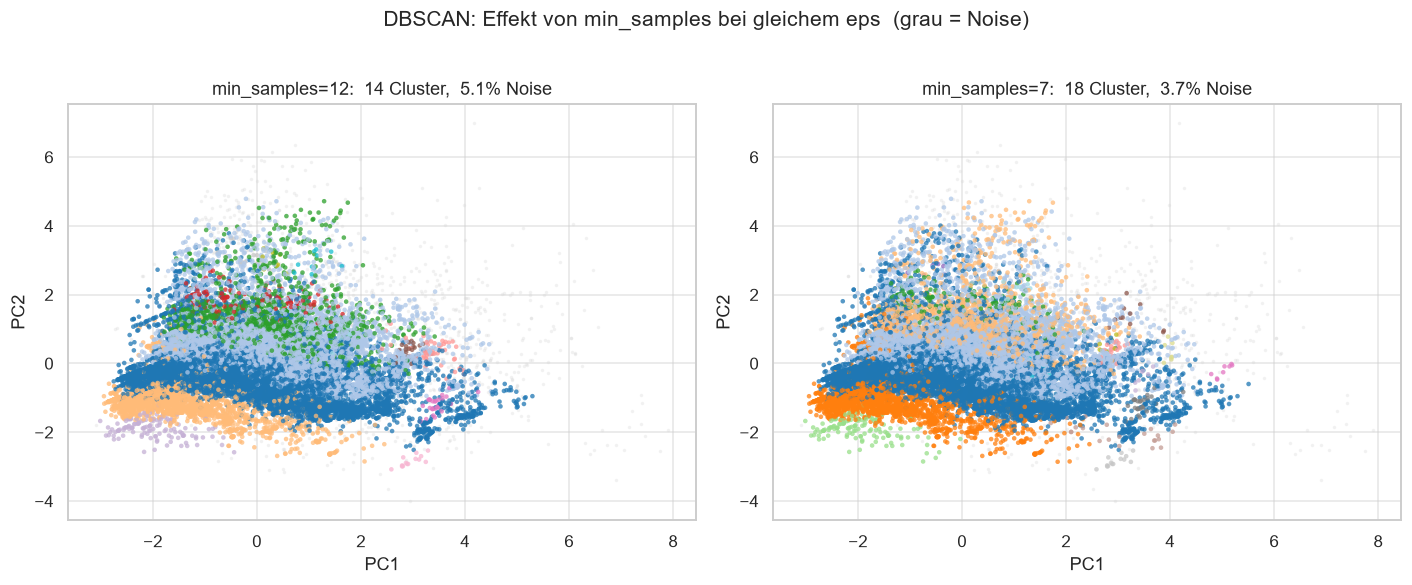

In [40]:
def plot_dbscan_panel(ms, eps_val, ax):
    lab = DBSCAN(eps=eps_val, min_samples=ms).fit(X).labels_
    noise = lab == -1
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    ax.scatter(X_pca[noise, 0], X_pca[noise, 1], c="lightgrey", s=5, alpha=.30, linewidths=0)
    ax.scatter(X_pca[~noise, 0], X_pca[~noise, 1], c=lab[~noise], cmap="tab20",
               s=9, alpha=.75, linewidths=0)
    ax.set_title(f"min_samples={ms}:  {nc} Cluster,  {noise.mean()*100:.1f}% Noise")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_dbscan_panel(ms_rule, eps_ref, axes[0])   # Faustregel 12
plot_dbscan_panel(ms_min,  eps_ref, axes[1])   # Untergrenze 7, gleiches eps
fig.suptitle("DBSCAN: Effekt von min_samples bei gleichem eps  (grau = Noise)",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

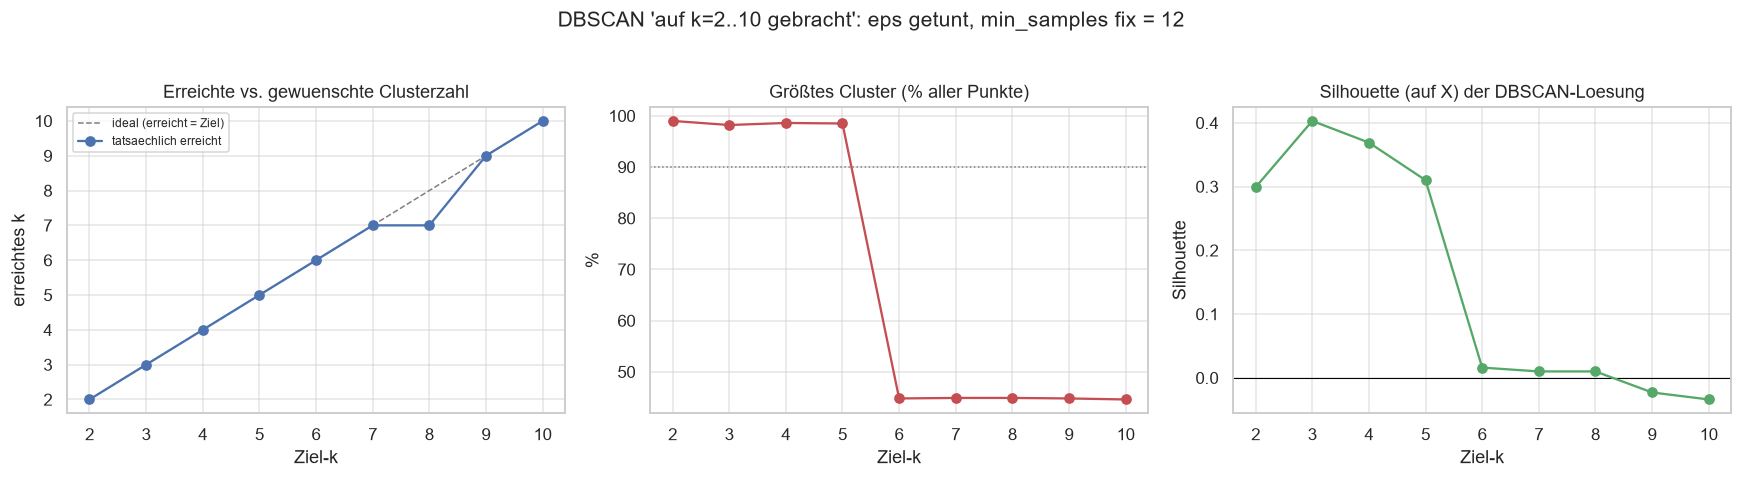

DBSCAN auf Ziel-Clusterzahl gebracht (min_samples fix = 12):
        erreichtes_k getroffen    eps  min_samples  Noise_%  größtes_Cl_%  \
Ziel_k                                                                      
2                  2        ja  1.304           12      0.8          99.0   
3                  3        ja  1.195           12      1.6          98.2   
4                  4        ja  1.267           12      1.0          98.6   
5                  5        ja  1.231           12      1.2          98.5   
6                  6        ja  1.049           12      3.2          44.8   
7                  7        ja  1.085           12      3.0          44.9   
8                  7      nein  1.085           12      3.0          44.9   
9                  9        ja  1.013           12      3.4          44.8   
10                10        ja  0.940           12      3.9          44.6   

        Silhouette_auf_X  
Ziel_k                    
2                  0.299  
3         

In [42]:
# =============================================================================
# "k = 2..10 bei DBSCAN?" - DBSCAN hat KEIN k als Parameter! Die Clusterzahl ist
# ein ERGEBNIS aus (eps, min_samples). Wir drehen an eps, bis DBSCAN moeglichst
# genau die Zielzahl liefert; min_samples bleibt fest = 2*n_features.
# KEIN evaluate() -> Haupt-Vergleichstabelle (results) bleibt unberuehrt.
# =============================================================================
def _sil_X_db(labels):
    """Silhouette im echten Feature-Raum X (Noise -1 ausgeschlossen)."""
    labels = np.asarray(labels); m = labels != -1
    if len(set(labels[m].tolist())) < 2:
        return np.nan
    try:
        return silhouette_score(X[m], labels[m],
                                sample_size=min(SIL_SAMPLE, int(m.sum())),
                                random_state=RANDOM_STATE)
    except ValueError:
        return np.nan

def _largest_share(labels):
    labels = np.asarray(labels); nn = labels[labels != -1]
    return 100 * np.bincount(nn).max() / len(labels) if len(nn) else 0.0

_ms_db = 2 * X.shape[1]                         # = 12

# eps-Raster aus der k-Distance-Verteilung: klein (Mikro-Cluster) bis gross (k=1)
_nn_db = NearestNeighbors(n_neighbors=_ms_db).fit(X)
_kd_db = np.sort(_nn_db.kneighbors(X)[0][:, -1])
eps_scan = np.linspace(np.percentile(_kd_db, 30), np.percentile(_kd_db, 99.5), 45)

# ---- db_runs AUFBAUEN: je eps einmal DBSCAN, k/Noise/Silhouette merken ----
db_runs = []
for e in eps_scan:
    lab = DBSCAN(eps=float(e), min_samples=_ms_db).fit(X).labels_
    db_runs.append({"eps": float(e),
                    "k": len(set(lab.tolist()) - {-1}),
                    "noise": float((lab == -1).mean()),
                    "sil": _sil_X_db(lab)})
db_runs = pd.DataFrame(db_runs)

# ---- Fuer jede Ziel-Clusterzahl die naechstbeste eps-Konfiguration waehlen ----
rows = []
for target in range(2, 11):
    cand = db_runs.assign(dist=(db_runs["k"] - target).abs())
    best = cand.sort_values(["dist", "noise"]).iloc[0]
    lab_b = DBSCAN(eps=float(best["eps"]), min_samples=_ms_db).fit(X).labels_
    rows.append({"Ziel_k": target,
                 "erreichtes_k": int(best["k"]),
                 "getroffen": "ja" if int(best["k"]) == target else "nein",
                 "eps": round(float(best["eps"]), 3),
                 "min_samples": _ms_db,
                 "Noise_%": round(best["noise"] * 100, 1),
                 "größtes_Cl_%": round(_largest_share(lab_b), 1),
                 "Silhouette_auf_X": round(best["sil"], 3) if pd.notna(best["sil"]) else np.nan})
dbscan_k_table = pd.DataFrame(rows).set_index("Ziel_k")

# ---- Visualisierung ----
tk = dbscan_k_table.index.to_numpy()
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(tk, tk, "--", color="grey", lw=1, label="ideal (erreicht = Ziel)")
ax[0].plot(tk, dbscan_k_table["erreichtes_k"], "o-", color="#4C72B0", label="tatsaechlich erreicht")
ax[0].set(title="Erreichte vs. gewuenschte Clusterzahl", xlabel="Ziel-k", ylabel="erreichtes k")
ax[0].legend(fontsize=8)
ax[1].plot(tk, dbscan_k_table["größtes_Cl_%"], "o-", color="#C44E52")
ax[1].axhline(90, color="grey", ls=":", lw=1)
ax[1].set(title="Größtes Cluster (% aller Punkte)", xlabel="Ziel-k", ylabel="%")
ax[2].axhline(0, color="black", lw=.7)
ax[2].plot(tk, dbscan_k_table["Silhouette_auf_X"], "o-", color="#55A868")
ax[2].set(title="Silhouette (auf X) der DBSCAN-Loesung", xlabel="Ziel-k", ylabel="Silhouette")
fig.suptitle("DBSCAN 'auf k=2..10 gebracht': eps getunt, min_samples fix = %d" % _ms_db,
             fontsize=14, y=1.03)
plt.tight_layout(); plt.show()

print("DBSCAN auf Ziel-Clusterzahl gebracht (min_samples fix = %d):" % _ms_db)
print(dbscan_k_table)
print("\nLesart: DBSCAN kennt kein k - die Zielzahl wird nur durch eps-Drehen angenaehert.")
print("Wo eine positive Silhouette steht, schluckt EIN Cluster ~99% der Punkte (Spalte größtes_Cl_%);")
print("die uebrigen 'Cluster' sind nur abgespaltene Ausreisser-Pockets, keine echten Segmente.")
print("-> DBSCAN findet keine ausgewogene Mehr-Segment-Partition: der Markt ist ein Kontinuum.")

In [43]:
_ms_db = 2 * X.shape[1]
for target in range(2, 11):
    cand = db_runs.assign(dist=(db_runs["k"] - target).abs())
    best = cand.sort_values(["dist", "noise"]).iloc[0]
    lab_b = DBSCAN(eps=float(best["eps"]), min_samples=_ms_db).fit(X).labels_
    rows.append({"Ziel_k": target, "erreichtes_k": int(best["k"]),
                 "getroffen": "ja" if int(best["k"]) == target else "nein",
                 "eps": round(float(best["eps"]), 3), "min_samples": _ms_db,
                 "Noise_%": round(best["noise"] * 100, 1),
                 "größtes_Cl_%": round(_largest_share(lab_b), 1),     # NEU
                 "Silhouette_auf_X": round(best["sil"], 3) if pd.notna(best["sil"]) else np.nan})

### 5.4 · HDBSCAN
Erweitert DBSCAN über verschiedene Dichte-Skalen und braucht kein festes `eps`. Wir steuern nur die minimale Clustergröße.

In [ ]:
hdb = HDBSCAN(min_cluster_size=250, min_samples=15).fit(X)
labels_hdb = evaluate("HDBSCAN", hdb.labels_)
plot_clusters(labels_hdb, "HDBSCAN")

### 5.6 · t-SNE-Projektion (nichtlinear, nur zur Visualisierung)
PC1/PC2 fangen nur einen Teil der Varianz ein, weshalb die Cluster im PCA-Bild stark überlappen. **t-SNE** ist eine nichtlineare Projektion, die lokale Nachbarschaften erhält und die Segmente optisch meist deutlich klarer trennt.

Wie die PCA dient t-SNE **nur der Visualisierung** – geclustert wird weiterhin auf allen 8 Features. Wichtig: t-SNE-Achsen und -Abstände sind **nicht** quantitativ interpretierbar (keine feste Bedeutung, kein „größer = teurer"), sie zeigen nur, *ob* sich Gruppen sauber separieren lassen.

In [ ]:
from sklearn.manifold import TSNE

# Visualisierung auf ALLEN 21.420 Objekten (kein Subsampling).
# Für einen schnelleren Lauf stattdessen eine Stichprobe ziehen, z. B.:
#   tsne_idx = np.random.default_rng(RANDOM_STATE).choice(len(X), size=6000, replace=False)
tsne_idx = np.arange(len(X))          # alle Punkte

# t-SNE ist rechenintensiv -> Fit auf 21k dauert ~30-40 s.
X_tsne = TSNE(n_components=2, perplexity=30, init="pca",
              learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X[tsne_idx])
print("t-SNE berechnet für", len(tsne_idx), "Punkte")

# Alle Verfahren im t-SNE-Raum nebeneinander (gleiche Labels, bessere Trennung)
runs = [("K-Means", labels_km), ("Hierarchical", labels_agg), ("DBSCAN", labels_db),
        ("HDBSCAN", labels_hdb), ("GMM", labels_gmm)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (name, lab) in zip(axes.ravel(), runs):
    plot_clusters(lab, name, emb=X_tsne, idx=tsne_idx, ax=ax,
                  xlabel="t-SNE 1", ylabel="t-SNE 2")
axes.ravel()[-1].axis("off")   # 6. Feld leer lassen
fig.suptitle(f"Cluster im t-SNE-Raum (alle n={len(tsne_idx):,} Objekte)",
             fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### 5.7 · UMAP-Projektion (Vergleich zu t-SNE)
**UMAP** ist eine zweite nichtlineare Projektion. Gegenüber t-SNE erhält es neben der lokalen auch die **globale** Struktur meist besser (Abstände zwischen Clustern sind etwas aussagekräftiger) und ist schneller. Wir rechnen es auf **denselben Punkten** (allen 21.420) wie t-SNE, damit der Vergleich fair ist.

Auch UMAP dient **nur der Visualisierung** – geclustert wird weiter auf allen 8 Features, und die Achsenwerte sind nicht quantitativ interpretierbar. Zeigen beide Projektionen (t-SNE *und* UMAP) dieselben Gruppen, ist das ein starkes Indiz, dass die Segmente **real** sind und kein Projektionsartefakt.

In [ ]:
import warnings
import umap

# Gleiche Punkte (tsne_idx = alle 21.420) wie t-SNE -> fairer Direktvergleich.
# UMAP-Fit auf 21k dauert ~40-60 s.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # numba-/UMAP-Hinweise unterdrücken
    X_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                       random_state=RANDOM_STATE).fit_transform(X[tsne_idx])
print("UMAP berechnet für", len(tsne_idx), "Punkte")

# a) Direktvergleich der beiden Projektionen am gewählten Verfahren (K-Means, k=4)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_clusters(labels_km, "K-Means · t-SNE", emb=X_tsne, idx=tsne_idx, ax=axes[0],
              xlabel="t-SNE 1", ylabel="t-SNE 2")
plot_clusters(labels_km, "K-Means · UMAP", emb=X_umap, idx=tsne_idx, ax=axes[1],
              xlabel="UMAP 1", ylabel="UMAP 2")
fig.suptitle(f"Projektions-Vergleich: t-SNE vs. UMAP (gleiche Punkte, K-Means k={K})",
             fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

# b) Alle Verfahren im UMAP-Raum (Pendant zum t-SNE-Grid oben; runs von dort wiederverwendet)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (name, lab) in zip(axes.ravel(), runs):
    plot_clusters(lab, name, emb=X_umap, idx=tsne_idx, ax=ax,
                  xlabel="UMAP 1", ylabel="UMAP 2")
axes.ravel()[-1].axis("off")
fig.suptitle(f"Cluster im UMAP-Raum (alle n={len(tsne_idx):,} Objekte)", fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### 5.8 · HDBSCAN gezielt auf ~4 Cluster gebracht (auf X vs. auf dem Embedding)

Oben (§5.4) laesst HDBSCAN die Clusterzahl frei und produziert auf den 8 Features sehr viel Noise. Hier bringen wir es **bewusst in Richtung 4 Segmente** und vergleichen zwei Wege:

- **A — auf allen 8 Features (`X`):** methodisch konsistent zur eigentlichen Segmentierung. Wir tunen nur `min_cluster_size` (groessere Mindestgroesse -> groebere, weniger Cluster) Richtung `k=4`.
- **B — direkt auf dem 2D-Embedding (t-SNE / UMAP):** die Projektion ist dicht und gut separiert, HDBSCAN findet dort fast immer saubere, kompakte Cluster und laesst sich leicht auf ~4 steuern. **Aber:** hier wird auf der *Projektion* geclustert, nicht auf den echten Features — Achsen/Abstaende sind nicht inhaltlich interpretierbar. Das ist eine **bewusste Zusatz-Analyse**, nicht die Haupt-Segmentierung.

Damit A und B fair vergleichbar bleiben, messen wir die **Silhouette bei beiden im echten 8-Feature-Raum `X`** (nicht im Embedding).

In [ ]:
# =============================================================================
# 5.8 · HDBSCAN "verbessert": gezielt auf ~4 Cluster gebracht
#   A) weiter auf allen 8 Features (X)          -> methodisch konsistent zur Segmentierung
#   B) direkt auf dem 2D-Embedding (t-SNE/UMAP) -> optisch sauber, aber auf der Projektion
# WICHTIG: Hier wird BEWUSST kein evaluate() aufgerufen -> die Haupt-Vergleichstabelle
#          (results / comparison) bleibt unberuehrt. Alle Kennzahlen lokal berechnet.
# =============================================================================

def hdbscan_to_k(data, target=K, min_samples=10,
                 sizes=(250, 400, 600, 900, 1400, 1600, 2000, 3000)):
    """Sucht die min_cluster_size, deren HDBSCAN-Ergebnis der Ziel-Clusterzahl am
    naechsten kommt (Tie-Break: weniger Noise). Gibt beste Wahl + alle Laeufe zurueck.
    HDBSCAN waehlt selbst, WIE VIELE Cluster; wir steuern nur ueber die minimale
    Clustergroesse, wie grob/fein aufgeloest wird -> so naehern wir uns k=4 an."""
    runs = []
    for mcs in sizes:
        lab = HDBSCAN(min_cluster_size=int(mcs), min_samples=min_samples).fit(data).labels_
        k = len(set(lab) - {-1})
        noise = float((lab == -1).mean())
        runs.append({"mcs": int(mcs), "k": k, "noise": noise, "labels": lab})
    runs.sort(key=lambda r: (abs(r["k"] - target), r["noise"]))
    return runs[0], runs

def sil_on_X(labels):
    """Silhouette IMMER im echten Feature-Raum X berechnen (fairer, vergleichbarer
    Massstab) - egal, worauf geclustert wurde. Noise (-1) ausgeschlossen."""
    labels = np.asarray(labels)
    m = labels != -1
    if len(set(labels[m].tolist())) < 2:
        return np.nan
    return silhouette_score(X[m], labels[m],
                            sample_size=min(SIL_SAMPLE, int(m.sum())),
                            random_state=RANDOM_STATE)

# --- A) HDBSCAN auf X (8 Features), Richtung k=4 getunt ---
bestA, sweepA = hdbscan_to_k(X)
labels_hdb_X = bestA["labels"]

# --- B) HDBSCAN auf den 2D-Projektionen, ebenfalls Richtung k=4 ---
bestT, sweepT = hdbscan_to_k(X_tsne)
labels_hdb_tsne = bestT["labels"]
bestU, sweepU = hdbscan_to_k(X_umap)
labels_hdb_umap = bestU["labels"]

hdb_summary = pd.DataFrame([
    {"Variante": "A - HDBSCAN auf X (8 Feat.)", "min_cluster_size": bestA["mcs"],
     "n_Cluster": bestA["k"], "Noise_%": round(bestA["noise"] * 100, 1),
     "Silhouette_auf_X": sil_on_X(labels_hdb_X)},
    {"Variante": "B - HDBSCAN auf t-SNE (2D)", "min_cluster_size": bestT["mcs"],
     "n_Cluster": bestT["k"], "Noise_%": round(bestT["noise"] * 100, 1),
     "Silhouette_auf_X": sil_on_X(labels_hdb_tsne)},
    {"Variante": "B - HDBSCAN auf UMAP (2D)", "min_cluster_size": bestU["mcs"],
     "n_Cluster": bestU["k"], "Noise_%": round(bestU["noise"] * 100, 1),
     "Silhouette_auf_X": sil_on_X(labels_hdb_umap)},
]).set_index("Variante").round(3)

print("Zielclusterzahl:", K)
print(hdb_summary)
print("\nHinweis: Silhouette wird bei allen Varianten im echten 8-Feature-Raum X gemessen,")
print("damit A und B vergleichbar sind - auch wenn B auf der 2D-Projektion geclustert hat.")


## 6 · Bewertung & Vergleich der Algorithmen
 Silhouette (höher = besser) und Davies-Bouldin (niedriger = besser). Noise = als Ausreißer markierte Punkte.

In [ ]:
comparison = pd.DataFrame(results).set_index("Algorithmus")
comparison = comparison.sort_values("Silhouette", ascending=False)
comparison.round(3)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
comparison["Silhouette"].plot.bar(ax=ax[0], color="#55A868")
ax[0].set_title("Silhouette (höher = besser)"); ax[0].tick_params(axis="x", rotation=30)
comparison["Davies_Bouldin"].plot.bar(ax=ax[1], color="#C44E52")
ax[1].set_title("Davies-Bouldin (niedriger = besser)"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 6.1 · Auswahl & Visualisierung der zwei besten Clusterings (Aufgabe – Deliverable 3)
„Beste" ≠ einfach höchste Silhouette. **DBSCAN** hat zwar die höchste Silhouette (0.41), markiert aber **~97 % der Objekte als Noise** – die Kennzahl bewertet dann nur eine kleine, dichte Rest-Insel und **nicht** unsere Segmentierung. Für die Aufgabe (Käufer in Segmente zerlegen) zählt nur ein Verfahren, das **(fast) jedem Objekt ein Segment zuordnet**.

Deshalb: Verfahren mit **> 30 % Noise ausschließen** (keine vollständige Segmentierung) und unter den verbleibenden die **zwei mit der besten Silhouette** wählen (Tie-Break: niedrigerer Davies-Bouldin). Diese zwei zeigen wir anschließend **sowohl in t-SNE als auch in UMAP**, um zu prüfen, ob beide Projektionen dieselbe Struktur bestätigen.

In [ ]:
# --- Auswahl der ZWEI BESTEN Clusterings ---
comp = pd.DataFrame(results).set_index("Algorithmus")
comp["Noise_%"] = (comp["Noise"] / len(X) * 100).round(1)

# Für eine Käufer-SEGMENTIERUNG muss (fast) jeder Punkt einem Segment gehören.
# DBSCAN/HDBSCAN markieren hier den Großteil als Noise -> ihre hohe Silhouette
# bewertet nur wenige dichte Restpunkte, NICHT die Segmentierung. Daher schließen
# wir Verfahren mit zu hohem Noise-Anteil aus (keine vollständige Segmentierung).
MAX_NOISE_FRAC = 0.30
valid = comp[comp["Noise"] / len(X) <= MAX_NOISE_FRAC]
ranked = valid.sort_values(["Silhouette", "Davies_Bouldin"], ascending=[False, True])
best_names = list(ranked.head(2).index)

print("Vollständige Segmentierungen (Noise <= 30 %), Rangfolge nach Silhouette:")
print(ranked[["n_Cluster", "Noise_%", "Silhouette", "Davies_Bouldin"]].round(3))
print("\nAusgeschlossen (zu viel Noise -> keine echte Segmentierung):",
      list(comp.index.difference(valid.index)))
print(">> Die zwei besten Clusterings:", best_names)

# --- Genau diese zwei in t-SNE UND UMAP visualisieren (Deliverable 3) ---
label_map = {"K-Means": labels_km, "Hierarchical": labels_agg, "DBSCAN": labels_db,
             "HDBSCAN": labels_hdb, "GMM": labels_gmm}

fig, axes = plt.subplots(len(best_names), 2, figsize=(13, 6 * len(best_names)))
axes = np.atleast_2d(axes)
for r, name in enumerate(best_names):
    plot_clusters(label_map[name], f"{name} · t-SNE", emb=X_tsne, idx=tsne_idx,
                  ax=axes[r, 0], xlabel="t-SNE 1", ylabel="t-SNE 2")
    plot_clusters(label_map[name], f"{name} · UMAP", emb=X_umap, idx=tsne_idx,
                  ax=axes[r, 1], xlabel="UMAP 1", ylabel="UMAP 2")
fig.suptitle(f"Die zwei besten Clusterings in t-SNE & UMAP: {best_names[0]} & {best_names[1]}",
             fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### 6.2 · Vorschlag: welches Clustering vertiefen? (Aufgabe – Deliverable 4)
Wir schlagen **K-Means (k=4)** für die hypothesengeleitete Vertiefung vor:

- **beste Silhouette** unter den vollständigen Segmentierungen, und **k=4** entspricht genau unseren vier Hypothesen **H1/H2/H3/H4**;
- **disjunkte, interpretierbare** Cluster (jedes Objekt genau einem Segment zugeordnet) – ideal, um Segment-Profile zu lesen;
- in **t-SNE *und* UMAP** zeigen sich dieselben Gruppen → die Segmente sind real, kein Projektionsartefakt.

**Hierarchical (Ward, k=4)** ist das Zweitplatzierte und dient als **Robustheits-Check** (liefert eine sehr ähnliche Partition). Die folgende **Profil-Analyse (Abschnitt 7)** ist genau dieser Deep-Dive auf das K-Means-Ergebnis – Abgleich der mittleren Feature-Werte je Cluster mit H1/H2/H3/H4.

## 7 · Cluster-Profile & Abgleich mit den Hypothesen
Wir nehmen die Zuordnung des am besten interpretierbaren Verfahrens (K-Means, k=4) und schauen uns die **mittleren (standardisierten) Feature-Werte je Cluster** an. Positiv = über Durchschnitt, negativ = darunter. Daraus lesen wir ab, welches Cluster zu H1/H2/H3/H4 passt.

In [ ]:
prof = df.copy()
prof["cluster"] = labels_km
profile = prof.groupby("cluster").mean()
sizes = prof["cluster"].value_counts().sort_index()
profile.insert(0, "n", sizes)
profile.round(2)

In [ ]:
# Interpretation je Cluster (aus den Profil-Mittelwerten oben abgeleitet, k=4).
# Deterministisch bei RANDOM_STATE=42; falls sich die Cluster-Nummern bei einem
# erneuten Lauf verschieben, hier einmal anpassen.
segment_names = {
    0: "Luxus (H3)",
    1: "Singles/Paare (H2)",
    2: "Familien (H1)",
    3: "Erstkäufer (H4)",
}

hm = profile.drop(columns="n").T          # Features = Zeilen (y), Cluster = Spalten (x)
xlabels = [f"Cluster {c}\n{segment_names.get(c, '?')}\n(n={int(profile.loc[c, 'n']):,})"
           for c in hm.columns]

plt.figure(figsize=(10, 4.2))
ax = sns.heatmap(hm, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                 cbar_kws={"shrink": .8})
ax.set_xticklabels(xlabels, rotation=0, fontsize=8)
plt.title("Cluster-Profile & Segment-Auswertung (Ø standardisierte Features je Cluster, k=4)")
plt.xlabel("Cluster / Segment-Auswertung"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()

### Interpretation der vier Segmente (k=4)
Die vier K-Means-Cluster ergeben vier klar voneinander getrennte Profile, die sich auf H1–H4 abbilden lassen (Werte = Ø standardisierte Features, +über / −unter Durchschnitt):

- **Cluster 0 → H3 Luxus** (n=4.679): durchweg hoch – `log_price` +1.23, `log_sqft_living` +1.15, `bathrooms` +0.99, `luxury_score` +1.02. Das teuerste, größte, am besten ausgestattete Segment. **Sehr klarer Treffer.**
- **Cluster 1 → H2 urbane Singles/Paare** (n=2.084): **zentrumsnah** (`distance_to_center` −0.81), so gut wie **kein Grundstück** (`yard` −1.62), kleine Fläche (−0.52), **frisch renoviert** (`years_since_renovation` −1.02), Preis ~Durchschnitt – zentrale, moderne Kleinwohnungen. **Klarer Treffer.**
- **Cluster 3 → H4 Erstkäufer** (n=6.853): **günstigstes** Segment (`log_price` −0.48), klein (`log_sqft_living` −0.86), wenige Bäder (−0.99), **ältester/unrenovierter** Bestand (+0.99) – das preiswerte Einstiegssegment. **Klarer Treffer.**
- **Cluster 2 → H1 Familien / Umland** (n=7.804, größtes Segment): definierendes Merkmal ist die **größte Distanz zum Zentrum** (`distance_to_center` +0.81); Grundstück (+0.34), Wohnfläche (+0.21) und Zimmerzahl (+0.15) liegen nur **leicht** über dem Durchschnitt. **Eingeschränkter Treffer:** eher „Wohnen im Umland" als ausgeprägt große Familienhäuser – das H1-Label stützt sich hier primär auf die **Lage**, nicht auf die Größe.

**Abgrenzung H2 vs. H4 (der kritische Punkt für k=4):** Beide sind „klein & zentral", trennen sich aber eindeutig über **Renovierungsalter und Preis** – H2 frisch renoviert (−1.02) und durchschnittspreisig, H4 alt/unrenoviert (+0.99) und am günstigsten. Es sind also **vier fachlich eigenständige Segmente**, keine künstliche Aufspaltung eines dritten – das stützt k=4 auch inhaltlich. Einzige Einschränkung: das Familien-Segment ist lage- statt größengetrieben.

### Klarere Segment-Darstellung: Snake-Plot & Radar-Charts
Da der t-SNE/UMAP-Scatter durch die Überlappung unscharf ist, zeigen wir die Trennschärfe über die **Cluster-Mittelwerte** – das macht die Segmente eindeutig sichtbar.

In [ ]:
# Snake-Plot: Profil-Linie je Cluster über alle Features (Klassiker der Segmentierung).
# Zeigt die Trennschärfe der Segmente viel klarer als der überlappende t-SNE/UMAP-Scatter,
# weil hier die CLUSTER-MITTELWERTE verglichen werden, nicht die Einzelpunkte.
prof_only = profile.drop(columns="n")
cmap = plt.get_cmap("tab10")

plt.figure(figsize=(11, 4.8))
for c in prof_only.index:
    plt.plot(prof_only.columns, prof_only.loc[c], "o-", linewidth=2, color=cmap(c % 10),
             label=f"Cluster {c} - {segment_names.get(c, '?')} (n={int(profile.loc[c, 'n']):,})")
plt.axhline(0, color="grey", lw=1, ls="--")           # 0 = Gesamtdurchschnitt
plt.xticks(rotation=30, ha="right")
plt.ylabel("Ø standardisierter Wert  (+ ueber / - unter Durchschnitt)")
plt.title("Snake-Plot: Segment-Profile je Cluster (K-Means, k=4)")
plt.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()


In [ ]:
# Radar-Charts: ein Netz je Segment (Persona-Darstellung).
# Gleiche radiale Skala fuer alle vier -> die Formen sind direkt vergleichbar.
feats = list(profile.drop(columns="n").columns)
N = len(feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]                      # Kreis schliessen

vals_all = profile.drop(columns="n").values
gmin, gmax = float(vals_all.min()) - 0.3, float(vals_all.max()) + 0.3
cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(2, 2, figsize=(12, 11), subplot_kw=dict(polar=True))
for ax, c in zip(axes.ravel(), profile.index):
    vals = profile.drop(columns="n").loc[c].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=cmap(c % 10))
    ax.fill(angles, vals, color=cmap(c % 10), alpha=0.25)
    ax.plot(angles, [0] * len(angles), color="grey", lw=1, ls="--")   # 0 = Durchschnitt
    ax.set_ylim(gmin, gmax)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feats, fontsize=7)
    ax.set_yticklabels([])
    ax.set_title(f"Cluster {c} - {segment_names.get(c, '?')}  (n={int(profile.loc[c, 'n']):,})",
                 fontsize=11, pad=22)
fig.suptitle("Segment-Steckbriefe als Radar-Charts (Ø standardisierte Features, k=4)",
             fontsize=14, y=1.0)
plt.tight_layout(); plt.show()
